## Simulação do Spark em Python 3.12.13

A simulação é uma implementação didática e simplificada, focada em demonstrar os conceitos do Spark usando Python puro. Ela utiliza Pandas para manipulação de dados, mas a estrutura de RDDs e DataFrames é construída para "imitar" o comportamento do Spark.

A simulação foi feita em `src/simulado.py`, e o notebook a seguir utiliza essa simulação para realizar a análise exploratória dos dados de COVID-19.

---
## Configuração do ambiente, caminhos, imports e extração .csv

In [ ]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, '../src')

# simulação do PySpark
from simulacao import (
    SimulatedSparkSession,
    SimulatedDataFrame,
    F,
    Window,
    RDD,
    REGIOES_AGREGADAS,
    criar_sessao,
    extrair,
    transformar,
    adicionar_media_movel,
    agregar_por_pais,
    agregar_mensal_global,
    agregar_por_continente,
)

# caminhos — resolve ROOT_DIR independentemente de onde o notebook é executado
_cwd = os.getcwd()
ROOT_DIR    = _cwd if os.path.basename(_cwd) != 'notebook' else os.path.abspath(os.path.join(_cwd, '..'))
CAMINHO_CSV = os.path.join(ROOT_DIR, 'data', 'owid-covid.csv')
DIR_FIGURAS = os.path.join(ROOT_DIR, 'figuras')
os.makedirs(DIR_FIGURAS, exist_ok=True)

# padrão dos gráficos seaborn e matplotlib
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (12, 6)})

print('Ambiente configurado com sucesso!')
print(f'Dataset: {CAMINHO_CSV}')
print(f'Figuras: {DIR_FIGURAS}')


Ambiente configurado com sucesso!
Dataset: /home/isabela-carone/Área de trabalho/repositorios-uvv/eda-covid19/eda-covid19/data/owid-covid.csv
Figuras: /home/isabela-carone/Área de trabalho/repositorios-uvv/eda-covid19/eda-covid19/figuras


---
## SparkSession e extração

Inicializa a **SparkSession >simulada<** e realiza a leitura do arquivo CSV.

> **Conceito Spark:** A `SparkSession` é o ponto de entrada de toda aplicação Spark. O método `builder.appName().master().getOrCreate()` é idêntico ao PySpark real.

In [ ]:
# Inicializa a SparkSession simulada (mesmo padrão builder do PySpark)
spark = criar_sessao()

# EXTRACT: lê o CSV via spark.read.csv() simulado
df_bruto = extrair(spark, CAMINHO_CSV)

# Visão geral do dataset
pdf_bruto = df_bruto._pdf
print(f'Linhas      : {df_bruto.count():,}')
print(f'Colunas     : {len(pdf_bruto.columns)}')
print(f'Países      : {pdf_bruto["country"].nunique()}')
print(f'Período     : {pdf_bruto["date"].min().date()} → {pdf_bruto["date"].max().date()}')
print(f'Continentes : {pdf_bruto["continent"].dropna().nunique()}')

print('\nSchema (simulação de printSchema):')
df_bruto.printSchema()

  SparkContext iniciado: master=local[*], app=EDA_COVID19_Simulado

  SimulatedSparkSession iniciada
  Versao  : 4.1.1-simulado
  Master  : local[*]
  App     : EDA_COVID19_Simulado


Linhas      : 570,606
Colunas     : 61
Países      : 262
Período     : 2020-01-01 → 2026-02-22
Continentes : 6

Schema (simulação de printSchema):
root
 |-- country: str (nullable = true)
 |-- date: datetime64[us] (nullable = true)
 |-- total_cases: float64 (nullable = true)
 |-- new_cases: float64 (nullable = true)
 |-- new_cases_smoothed: float64 (nullable = true)
 |-- total_cases_per_million: float64 (nullable = true)
 |-- new_cases_per_million: float64 (nullable = true)
 |-- new_cases_smoothed_per_million: float64 (nullable = true)
 |-- total_deaths: float64 (nullable = true)
 |-- new_deaths: float64 (nullable = true)
 |-- new_deaths_smoothed: float64 (nullable = true)
 |-- total_deaths_per_million: float64 (nullable = true)
 |-- new_deaths_per_million: float64 (nullable = true)
 |-- new_deaths_smoothed_per_million: float64 (nullable = true)
 |-- excess_mortality: float64 (nullable = true)
 |-- excess_mortality_cumulative: float64 (nullable = true)
 |-- excess_mortality_cumulative_

---
## Retirada dos valores nulos de cada coluna

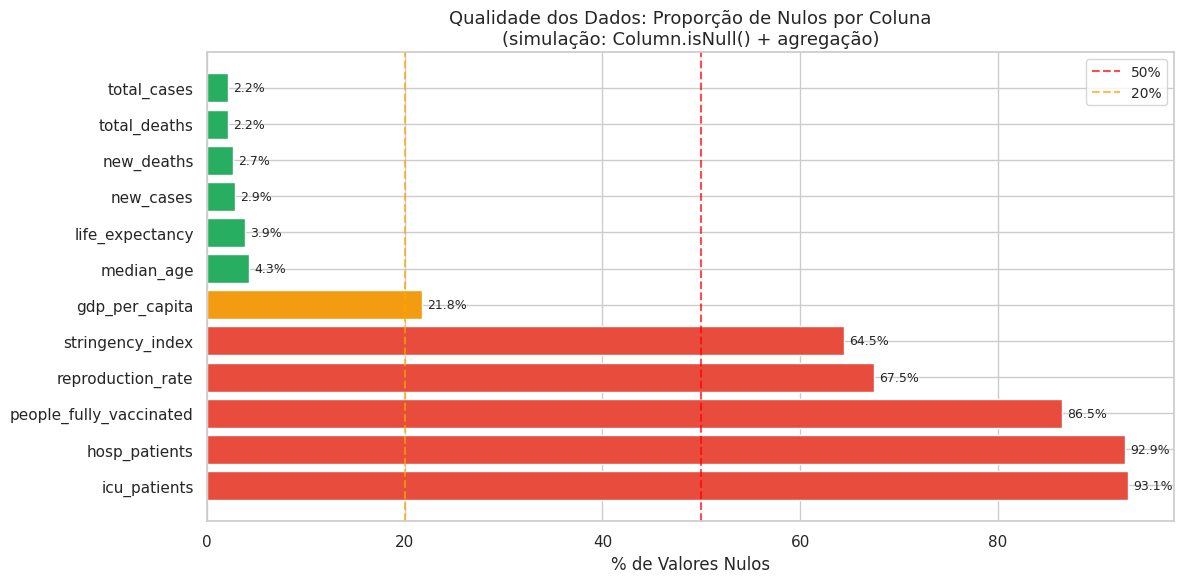

Figura salva: 01_valores_nulos_sim.png


In [ ]:
# Calcula a proporção de nulos em colunas selecionadas
colunas_analise = [
    'total_cases', 'new_cases', 'total_deaths', 'new_deaths',
    'people_fully_vaccinated', 'hosp_patients', 'icu_patients',
    'stringency_index', 'reproduction_rate', 'gdp_per_capita',
    'median_age', 'life_expectancy',
]

colunas_existentes = [c for c in colunas_analise if c in pdf_bruto.columns]
total = len(pdf_bruto)

nulos_df = pd.DataFrame({
    'coluna': colunas_existentes,
    'pct_nulos': [
        pdf_bruto[c].isna().sum() / total * 100
        for c in colunas_existentes
    ]
}).sort_values('pct_nulos', ascending=False)

# GRÁFICO 01 — Proporção de valores nulos
fig, ax = plt.subplots(figsize=(12, 6))
cores = ['#e74c3c' if v > 50 else '#f39c12' if v > 20 else '#27ae60'
         for v in nulos_df['pct_nulos']]
ax.barh(nulos_df['coluna'], nulos_df['pct_nulos'], color=cores)
ax.set_xlabel('% de Valores Nulos', fontsize=12)
ax.set_title('Qualidade dos Dados: Proporção de Nulos por Coluna\n(simulação: Column.isNull() + agregação)', fontsize=13)
ax.axvline(50, color='red', linestyle='--', alpha=0.7, label='50%')
ax.axvline(20, color='orange', linestyle='--', alpha=0.7, label='20%')
ax.legend(fontsize=10)
for i, (_, row) in enumerate(nulos_df.iterrows()):
    ax.text(row['pct_nulos'] + 0.5, i, f"{row['pct_nulos']:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '01_valores_nulos_sim.png'), dpi=120)
plt.show()
print('Figura salva: 01_valores_nulos_sim.png')


---
## Transformação: limpeza e transformação dos dados

> **Conceito Spark:** `.filter()`, `.withColumn()`, `F.when().otherwise()` — todas implementadas na classe `SimulatedDataFrame`.

In [ ]:
# TRANSFORM — aplica filtros e cria colunas derivadas
df_limpo = transformar(df_bruto)

# Window Function — média móvel 7 dias por país
print('\nCalculando média móvel 7 dias (Window Function simulada)...')
df_completo = adicionar_media_movel(df_limpo, 'new_cases', 7)
df_completo = adicionar_media_movel(df_completo, 'new_deaths', 7)

pdf = df_completo._pdf
print(f'\nDataset transformado: {len(pdf):,} linhas × {len(pdf.columns)} colunas')
print(f'Novas colunas: year_month, year, daily_mortality_rate, fully_vaccinated_pct,')
print(f'               new_cases_ma7, new_deaths_ma7')

Transformação (DataFrame API - alto nivel)


  Após remover regioes : 528,390


  Após remover neg.: 528,390


  Colunas adicionadas: year_month, year, daily_mortality_rate, fully_vaccinated_pct


Calculando média móvel 7 dias (Window Function simulada)...



Dataset transformado: 528,390 linhas × 67 colunas
Novas colunas: year_month, year, daily_mortality_rate, fully_vaccinated_pct,
               new_cases_ma7, new_deaths_ma7


---
## Seção 4: Agregações (groupBy + agg)

> **Conceito Spark:** `.groupBy().agg(F.max(), F.avg(), ...)` — cada `AggExpr` é calculada independentemente e unida por merge, simulando o plano paralelo do Spark.

In [ ]:
# Agrega por país
df_pais = agregar_por_pais(df_completo)
pdf_pais = df_pais._pdf.dropna(subset=['total_cases'])

# Agrega por continente
df_cont = agregar_por_continente(df_completo)
pdf_cont = df_cont._pdf.dropna(subset=['total_cases'])

# Agrega mensalmente
df_mensal = agregar_mensal_global(df_completo)
pdf_mensal = df_mensal._pdf.dropna(subset=['global_new_cases'])

print(f'Países com dados: {len(pdf_pais)}')
print(f'Continentes     : {len(pdf_cont)}')
print(f'Meses           : {len(pdf_mensal)}')

print('\nTop 5 países por total de casos:')
print(pdf_pais.nlargest(5, 'total_cases')[['country', 'continent', 'total_cases', 'total_deaths']].to_string(index=False))

Países com dados: 191
Continentes     : 6
Meses           : 74

Top 5 países por total de casos:
      country     continent  total_cases  total_deaths
United States North America  103436829.0     1235885.0
        China          Asia   99381761.0      122398.0
        India          Asia   45056126.0      533847.0
       France        Europe   39058710.0      168202.0
      Germany        Europe   38437952.0      174979.0


---
## Seção 5: Demonstração RDD / MapReduce

Esta seção demonstra o modelo de baixo nível do Spark: o **RDD (Resilient Distributed Dataset)**.

> **Conceito Spark:** No RDD real, os dados são divididos em partições e processadas em paralelo por executores diferentes no cluster. Aqui simulamos esse comportamento com listas Python particionadas.

In [ ]:
# FASE MAP ccria pares 
pdf_amostra = pdf_bruto[pdf_bruto['continent'].notna()].head(10_000)
registros   = pdf_amostra.to_dict(orient='records')

rdd_covid = spark.sparkContext.parallelize(registros, num_slices=4)
print(f'RDD criado: {rdd_covid}')
print(f'Número de partições: {rdd_covid.num_partitions}')
print(f'Tamanho de cada partição: ~{len(registros)//4:,} registros')

# MAP: extrai (país, novos_casos)
rdd_pares = rdd_covid.map(
    lambda r: (r['country'], r['new_cases'] if pd.notna(r['new_cases']) else 0)
)
print(f'\n[MAP] Exemplo de pares: {rdd_pares.take(3)}')

# REDUCE: soma por país
total_por_pais = rdd_pares.reduceByKey(lambda valores: sum(valores))
top10_rdd = sorted(total_por_pais.items(), key=lambda x: -x[1])[:10]

print('\n[REDUCE] Top 10 países — soma de novos casos (amostra 10k registros):')
for pais, total in top10_rdd:
    print(f'  {pais:<25}: {total:>12,.0f} casos')

RDD criado: SimulatedRDD[10000 registros em 4 particoes]
Número de partições: 4
Tamanho de cada partição: ~2,500 registros

[MAP] Exemplo de pares: [('Afghanistan', 0), ('Afghanistan', 0), ('Afghanistan', 0)]

[REDUCE] Top 10 países — soma de novos casos (amostra 10k registros):
  Albania                  :      337,234 casos
  Algeria                  :      272,435 casos
  Afghanistan              :      235,214 casos
  Andorra                  :       46,366 casos
  American Samoa           :        8,359 casos


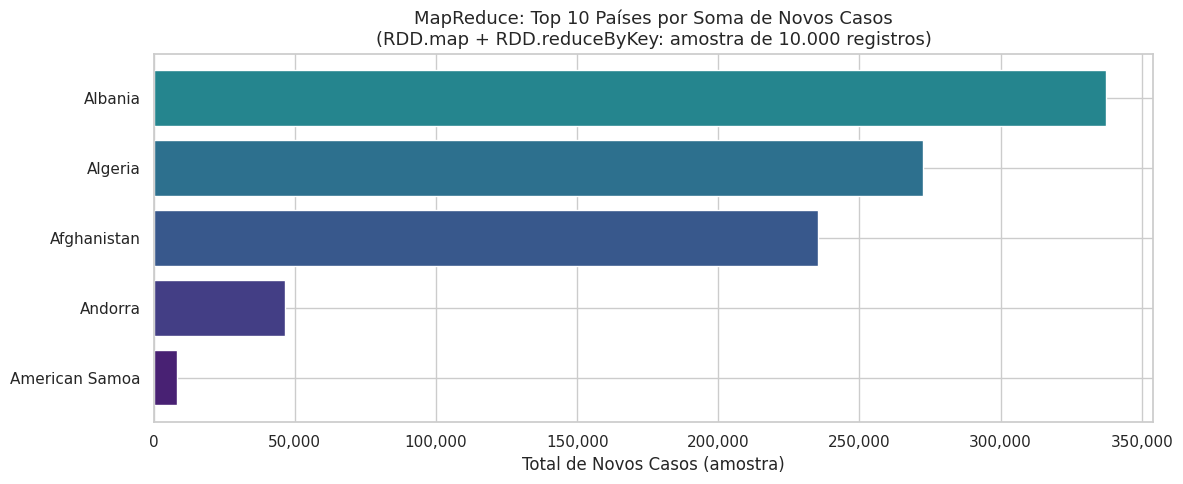

Figura salva: 02_mapreduce_sim.png


In [ ]:
# GRÁFICO 02 Visualização do resultado MapReduce
rdd_df = pd.DataFrame(top10_rdd, columns=['pais', 'total_casos'])

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(rdd_df['pais'][::-1], rdd_df['total_casos'][::-1],
               color=sns.color_palette('viridis', 10))
ax.set_xlabel('Total de Novos Casos (amostra)', fontsize=12)
ax.set_title('MapReduce: Top 10 Países por Soma de Novos Casos\n(RDD.map + RDD.reduceByKey: amostra de 10.000 registros)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '02_mapreduce_sim.png'), dpi=120)
plt.show()
print('Figura salva: 02_mapreduce_sim.png')

---
## Seção 6: Evolução Global de Casos e Mortes

Evolução temporal dos novos casos e mortes **no mundo inteiro**, usando dados mensais agregados.

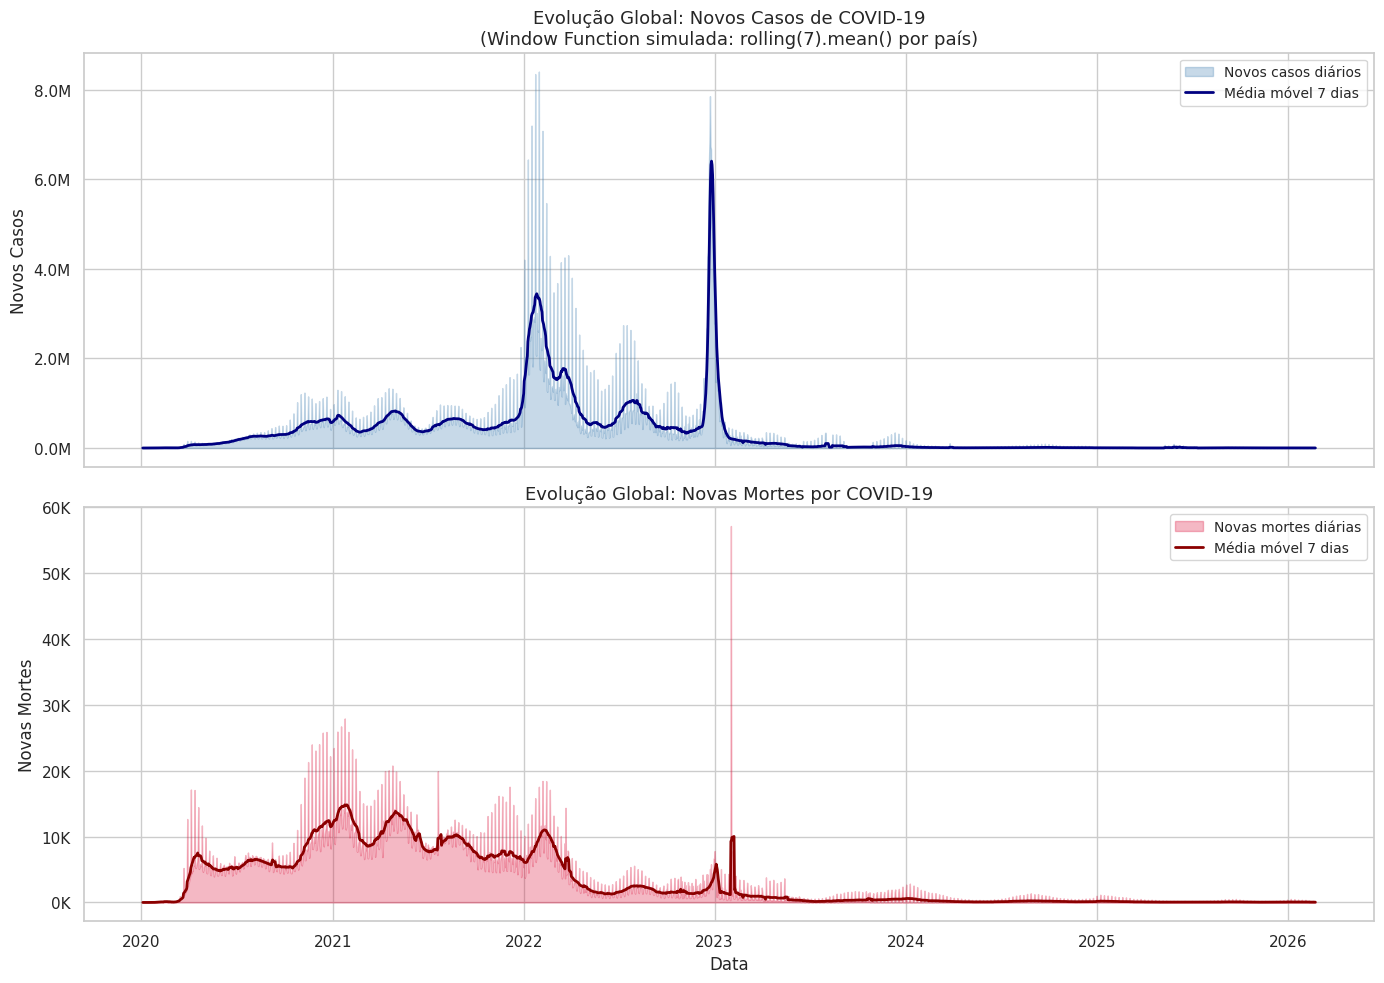

Figura salva: 03_evolucao_global_sim.png


In [ ]:
# Usa dados do dataset bruto filtrando pelo agregado 'World'
pdf_world = pdf_bruto[pdf_bruto['country'] == 'World'].copy()
pdf_world = pdf_world.dropna(subset=['new_cases'])
pdf_world['new_cases_ma7'] = pdf_world['new_cases'].rolling(7, min_periods=1).mean()
pdf_world['new_deaths_ma7'] = pdf_world['new_deaths'].rolling(7, min_periods=1).mean()

# GRÁFICO 03 — Evolução global (casos e mortes)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].fill_between(pdf_world['date'], pdf_world['new_cases'],
                     alpha=0.3, color='steelblue', label='Novos casos diários')
axes[0].plot(pdf_world['date'], pdf_world['new_cases_ma7'],
             color='navy', linewidth=2, label='Média móvel 7 dias')
axes[0].set_ylabel('Novos Casos', fontsize=12)
axes[0].set_title('Evolução Global: Novos Casos de COVID-19\n(Window Function simulada: rolling(7).mean() por país)', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[1].fill_between(pdf_world['date'], pdf_world['new_deaths'],
                     alpha=0.3, color='crimson', label='Novas mortes diárias')
axes[1].plot(pdf_world['date'], pdf_world['new_deaths_ma7'],
             color='darkred', linewidth=2, label='Média móvel 7 dias')
axes[1].set_ylabel('Novas Mortes', fontsize=12)
axes[1].set_xlabel('Data', fontsize=12)
axes[1].set_title('Evolução Global: Novas Mortes por COVID-19', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '03_evolucao_global_sim.png'), dpi=120)
plt.show()
print('Figura salva: 03_evolucao_global_sim.png')

---
## Seção 7: Evolução Mensal Global

Agrega os novos casos mensalmente usando `groupBy('year_month').agg(F.sum('new_cases'))`.

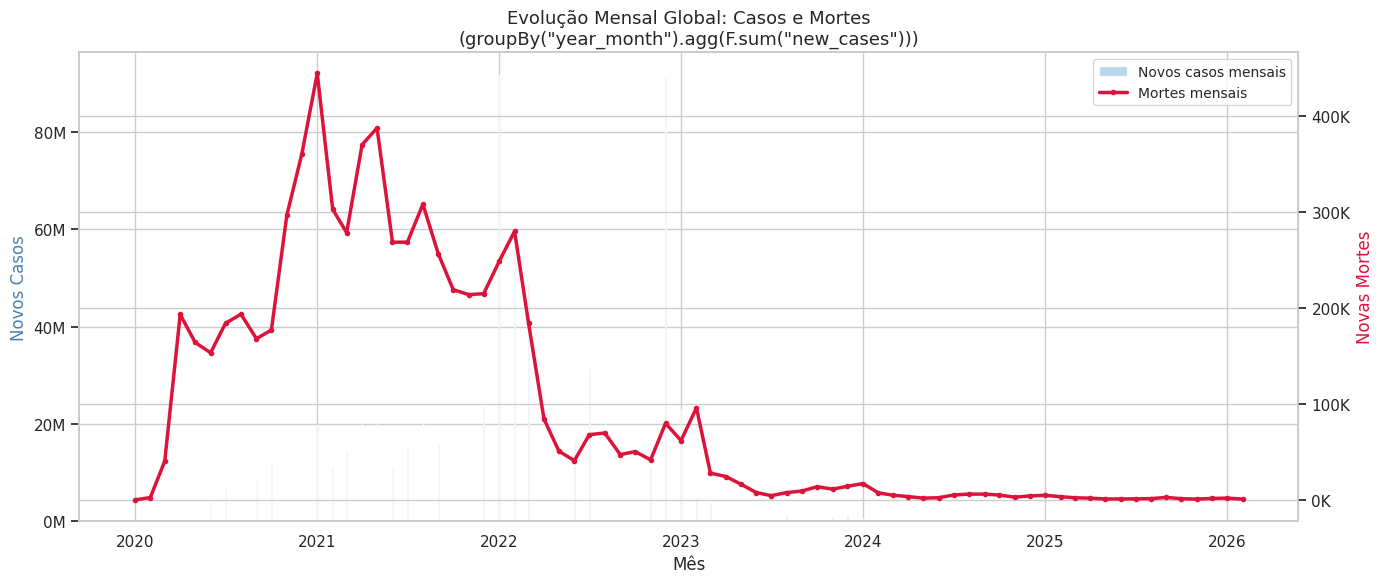

Figura salva: 04_evolucao_mensal_sim.png


In [ ]:
# GRÁFICO 04 — Evolução mensal global (groupBy + F.sum)
pdf_mensal_plot = pdf_mensal[pdf_mensal['global_new_cases'] > 0].copy()

# Converte year_month para datetime para ordenação correta no eixo x
pdf_mensal_plot['mes_dt'] = pd.to_datetime(pdf_mensal_plot['year_month'] + '-01')
pdf_mensal_plot = pdf_mensal_plot.sort_values('mes_dt')

fig, ax1 = plt.subplots(figsize=(14, 6))

cores_bar = sns.color_palette('Blues_d', len(pdf_mensal_plot))
ax1.bar(pdf_mensal_plot['mes_dt'], pdf_mensal_plot['global_new_cases'],
        color=cores_bar, alpha=0.8, label='Novos casos mensais')
ax1.set_ylabel('Novos Casos', fontsize=12, color='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

ax2 = ax1.twinx()
ax2.plot(pdf_mensal_plot['mes_dt'], pdf_mensal_plot['global_new_deaths'],
         color='crimson', linewidth=2.5, marker='o', markersize=3, label='Mortes mensais')
ax2.set_ylabel('Novas Mortes', fontsize=12, color='crimson')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

ax1.set_xlabel('Mês', fontsize=12)
ax1.set_title('Evolução Mensal Global: Casos e Mortes\n(groupBy("year_month").agg(F.sum("new_cases")))', fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '04_evolucao_mensal_sim.png'), dpi=120)
plt.show()
print('Figura salva: 04_evolucao_mensal_sim.png')

---
## Seção 8: Top 15 Países por Total de Casos e Mortes

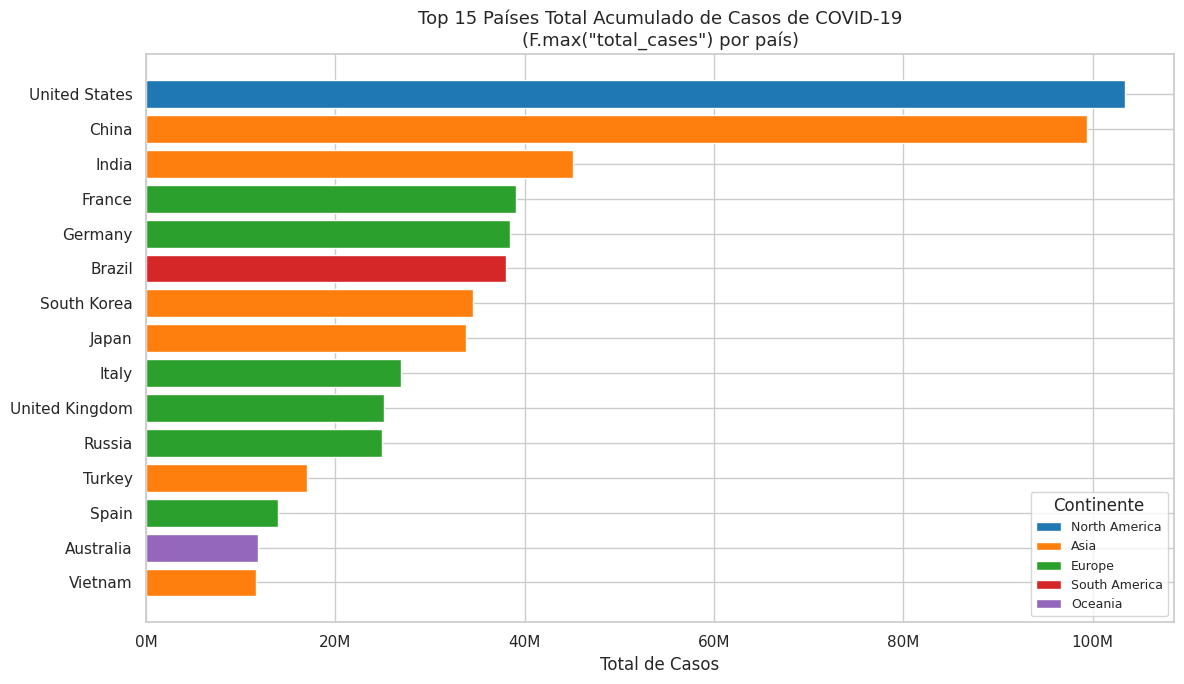

Figura salva: 05_top15_casos_sim.png


In [ ]:
# GRÁFICO 05 Top 15 países por total de casos
top15_casos = pdf_pais.nlargest(15, 'total_cases')[['country', 'continent', 'total_cases']]

fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette('tab10', len(top15_casos['continent'].unique()))
cont_cores = {c: palette[i] for i, c in enumerate(top15_casos['continent'].unique())}
cores = [cont_cores[c] for c in top15_casos['continent']]

bars = ax.barh(top15_casos['country'][::-1], top15_casos['total_cases'][::-1], color=cores[::-1])
ax.set_xlabel('Total de Casos', fontsize=12)
ax.set_title('Top 15 Países Total Acumulado de Casos de COVID-19\n(F.max("total_cases") por país)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in cont_cores.items()]
ax.legend(handles=legend_elements, title='Continente', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '05_top15_casos_sim.png'), dpi=120)
plt.show()
print('Figura salva: 05_top15_casos_sim.png')

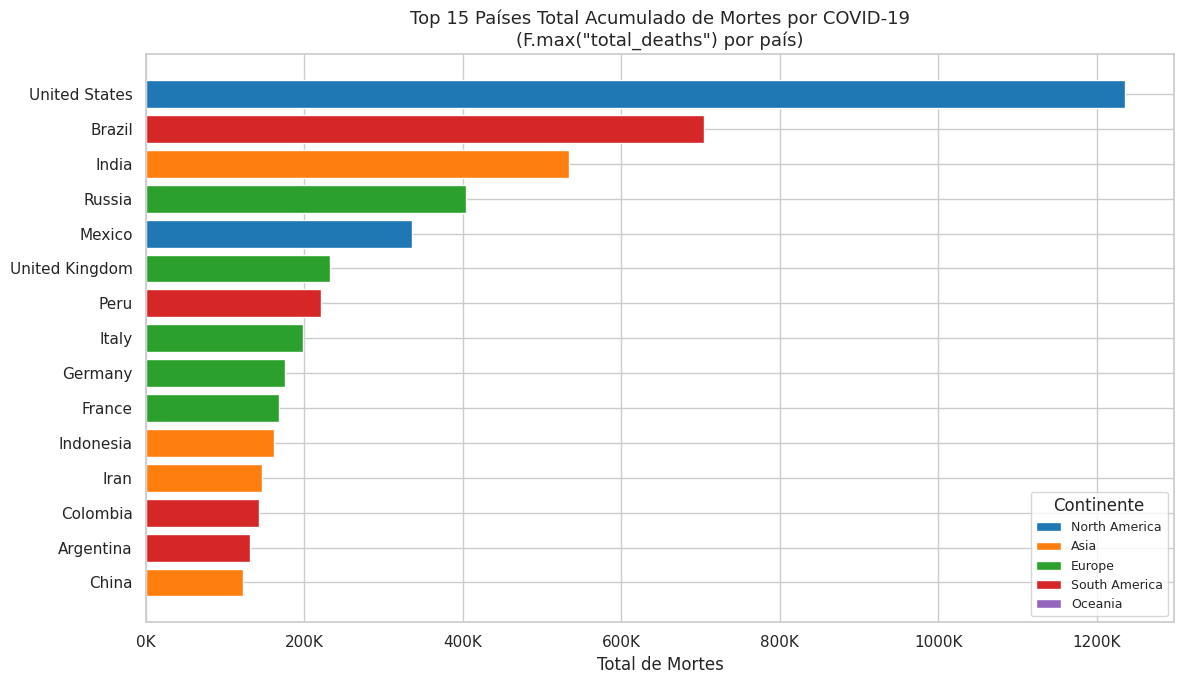

Figura salva: 06_top15_mortes_sim.png


In [ ]:
# GRÁFICO 06 Top 15 países por total de mortes
top15_mortes = pdf_pais.dropna(subset=['total_deaths']).nlargest(15, 'total_deaths')

fig, ax = plt.subplots(figsize=(12, 7))
cores_m = [cont_cores.get(c, 'gray') for c in top15_mortes['continent']]
ax.barh(top15_mortes['country'][::-1], top15_mortes['total_deaths'][::-1], color=cores_m[::-1])
ax.set_xlabel('Total de Mortes', fontsize=12)
ax.set_title('Top 15 Países Total Acumulado de Mortes por COVID-19\n(F.max("total_deaths") por país)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.legend(handles=legend_elements, title='Continente', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '06_top15_mortes_sim.png'), dpi=120)
plt.show()
print('Figura salva: 06_top15_mortes_sim.png')

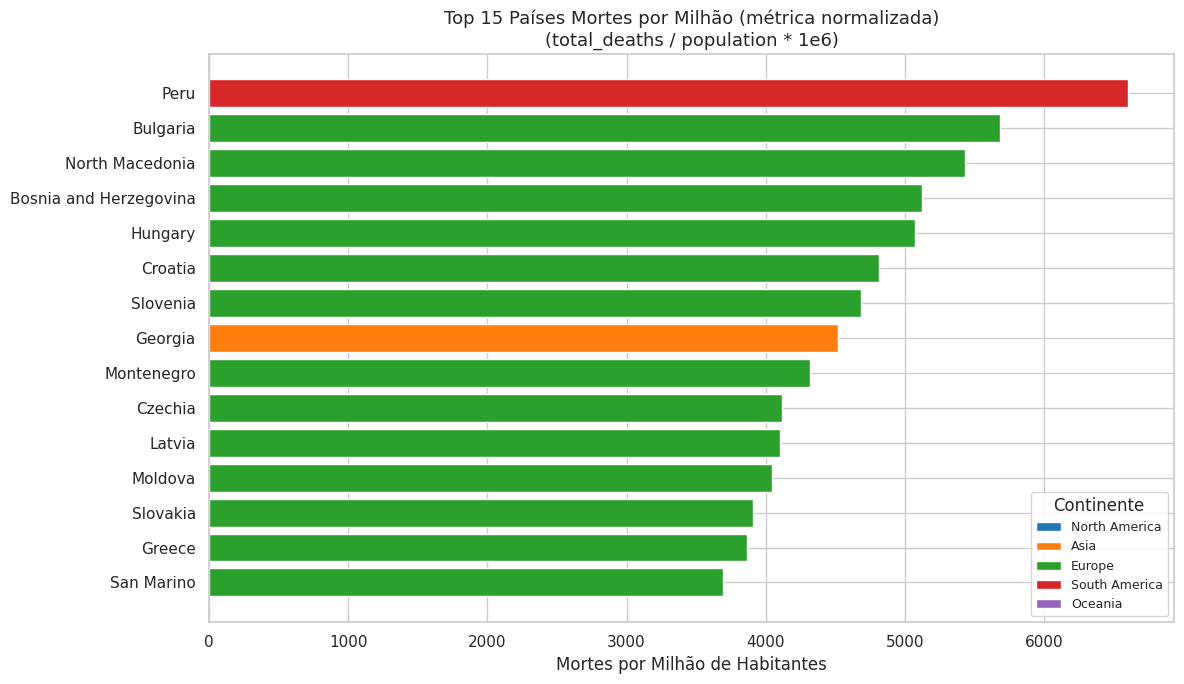

Figura salva: 07_top15_mortes_por_milhao_sim.png


In [ ]:
# GRÁFICO 07 Top 15 países por mortes por milhão (normalizado por população)
pdf_pais_calc = pdf_pais.copy()
pdf_pais_calc['mortes_por_milhao'] = (
    pdf_pais_calc['total_deaths'] / pdf_pais_calc['population'] * 1_000_000
)
top15_mpm = pdf_pais_calc.dropna(subset=['mortes_por_milhao']).nlargest(15, 'mortes_por_milhao')

fig, ax = plt.subplots(figsize=(12, 7))
cores_mpm = [cont_cores.get(c, 'gray') for c in top15_mpm['continent']]
ax.barh(top15_mpm['country'][::-1], top15_mpm['mortes_por_milhao'][::-1], color=cores_mpm[::-1])
ax.set_xlabel('Mortes por Milhão de Habitantes', fontsize=12)
ax.set_title('Top 15 Países Mortes por Milhão (métrica normalizada)\n(total_deaths / population * 1e6)', fontsize=13)
ax.legend(handles=legend_elements, title='Continente', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '07_top15_mortes_por_milhao_sim.png'), dpi=120)
plt.show()
print('Figura salva: 07_top15_mortes_por_milhao_sim.png')

---
## Seção 9: Análise por Continente

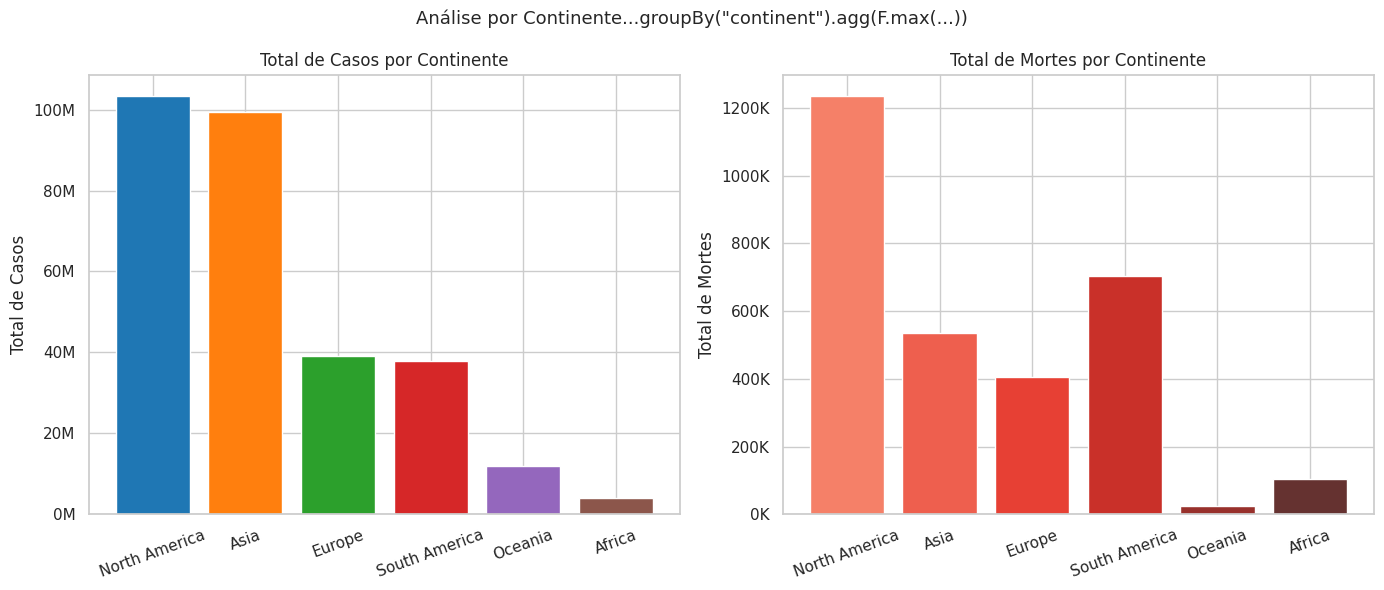

Figura salva: 08_analise_continentes_sim.png


In [ ]:
# GRÁFICO 08 Casos e mortes totais por continente
pdf_cont_plot = pdf_cont.sort_values('total_cases', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(pdf_cont_plot['continent'], pdf_cont_plot['total_cases'],
            color=sns.color_palette('tab10', len(pdf_cont_plot)))
axes[0].set_title('Total de Casos por Continente', fontsize=12)
axes[0].set_ylabel('Total de Casos')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(pdf_cont_plot['continent'], pdf_cont_plot['total_deaths'],
            color=sns.color_palette('Reds_d', len(pdf_cont_plot)))
axes[1].set_title('Total de Mortes por Continente', fontsize=12)
axes[1].set_ylabel('Total de Mortes')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].tick_params(axis='x', rotation=20)

fig.suptitle('Análise por Continente...groupBy("continent").agg(F.max(...))', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '08_analise_continentes_sim.png'), dpi=120)
plt.show()
print('Figura salva: 08_analise_continentes_sim.png')

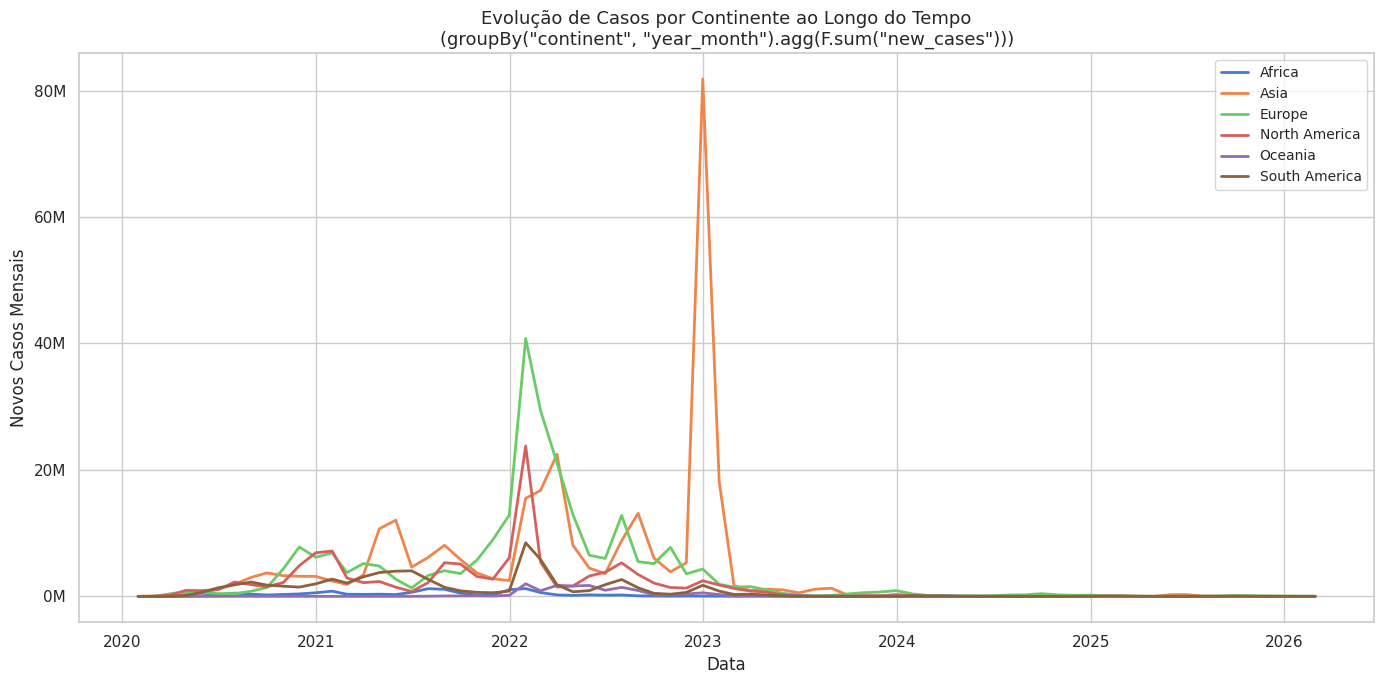

Figura salva: 09_casos_por_continente_tempo_sim.png


In [ ]:
# GRÁFICO 09 Evolução de casos por continente ao longo do tempo
continentes = pdf_bruto['continent'].dropna().unique()

# Agrega casos mensais por continente diretamente do pandas
pdf_cont_tempo = (
    pdf_bruto[pdf_bruto['continent'].notna()]
    .groupby(['continent', pd.Grouper(key='date', freq='ME')])
    ['new_cases'].sum().reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))
for cont in sorted(continentes):
    dados_cont = pdf_cont_tempo[pdf_cont_tempo['continent'] == cont]
    ax.plot(dados_cont['date'], dados_cont['new_cases'],
            label=cont, linewidth=2)

ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Novos Casos Mensais', fontsize=12)
ax.set_title('Evolução de Casos por Continente ao Longo do Tempo\n(groupBy("continent", "year_month").agg(F.sum("new_cases")))', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '09_casos_por_continente_tempo_sim.png'), dpi=120)
plt.show()
print('Figura salva: 09_casos_por_continente_tempo_sim.png')

---
## Seção 10: Análise de Vacinação Global

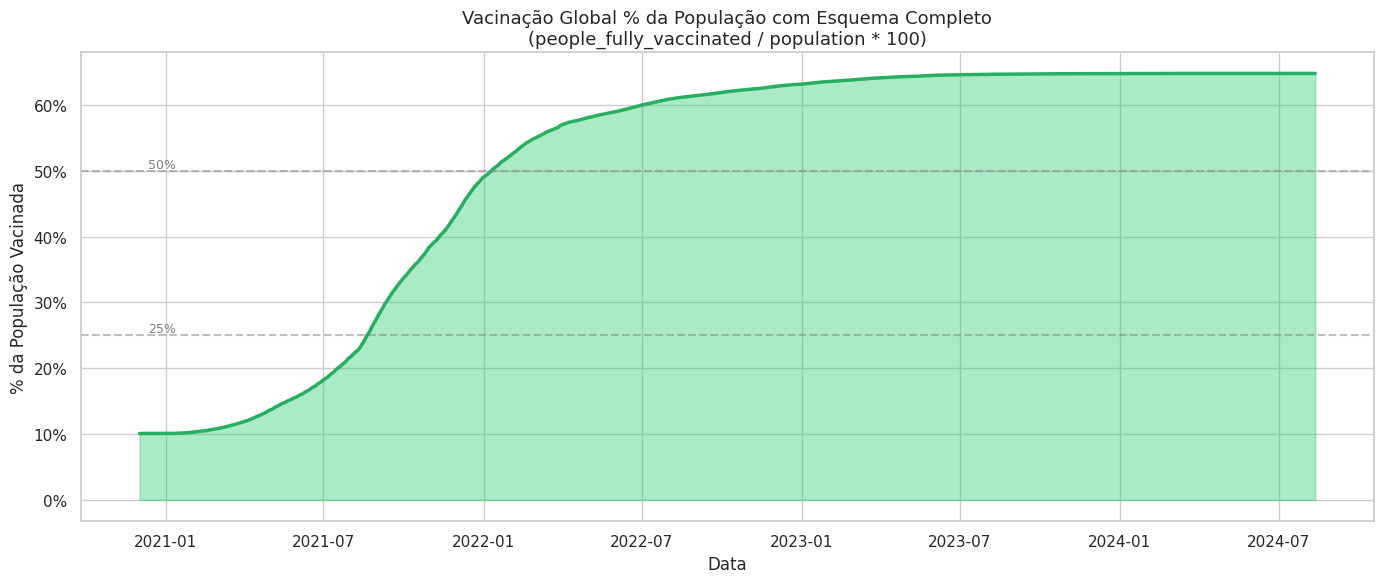

Figura salva: 10_vacinacao_global_sim.png


In [ ]:
# GRÁFICO 10 Vacinação global ao longo do tempo
pdf_world_vac = (
    pdf_bruto[pdf_bruto['country'] == 'World']
    .dropna(subset=['people_fully_vaccinated'])
    .copy()
)
pdf_world_vac['pct_vacinados'] = (
    pdf_world_vac['people_fully_vaccinated'] /
    pdf_world_vac['population'] * 100
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(pdf_world_vac['date'], pdf_world_vac['pct_vacinados'],
                color='#2ecc71', alpha=0.4)
ax.plot(pdf_world_vac['date'], pdf_world_vac['pct_vacinados'],
        color='#27ae60', linewidth=2.5)
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('% da População Vacinada', fontsize=12)
ax.set_title('Vacinação Global % da População com Esquema Completo\n(people_fully_vaccinated / population * 100)', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Anotações de marcos de vacinação
for pct, label in [(25, '25%'), (50, '50%'), (70, '70%')]:
    if pdf_world_vac['pct_vacinados'].max() >= pct:
        ax.axhline(pct, color='gray', linestyle='--', alpha=0.5)
        ax.text(pdf_world_vac['date'].iloc[10], pct + 0.5, label,
                fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '10_vacinacao_global_sim.png'), dpi=120)
plt.show()
print('Figura salva: 10_vacinacao_global_sim.png')

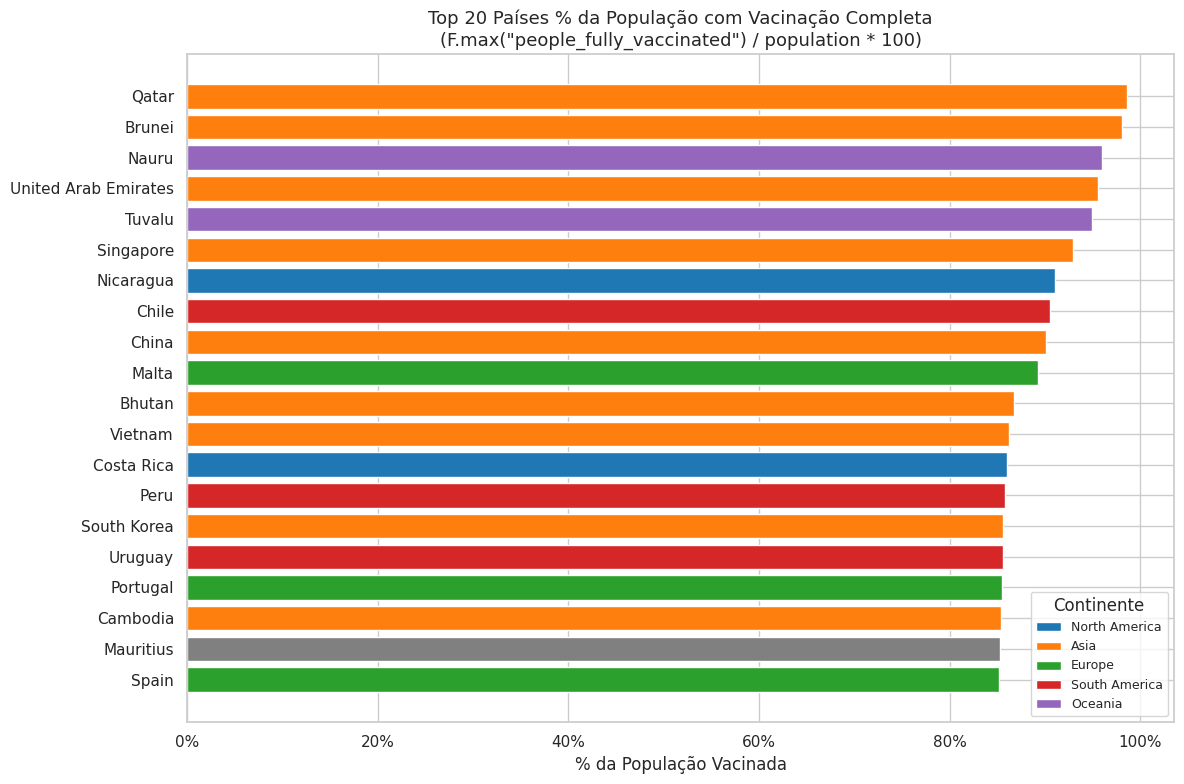

Figura salva: 11_top20_vacinacao_sim.png


In [ ]:
# GRÁFICO 11 Top 20 países por % de vacinação
pdf_pais_vac = pdf_pais.copy()
pdf_pais_vac['pct_vacinados'] = (
    pdf_pais_vac['people_fully_vaccinated'] /
    pdf_pais_vac['population'] * 100
)
top20_vac = (
    pdf_pais_vac
    .dropna(subset=['pct_vacinados'])
    .query('pct_vacinados <= 100')
    .nlargest(20, 'pct_vacinados')
)

fig, ax = plt.subplots(figsize=(12, 8))
cores_vac = [cont_cores.get(c, 'gray') for c in top20_vac['continent']]
ax.barh(top20_vac['country'][::-1], top20_vac['pct_vacinados'][::-1], color=cores_vac[::-1])
ax.set_xlabel('% da População Vacinada', fontsize=12)
ax.set_title('Top 20 Países % da População com Vacinação Completa\n(F.max("people_fully_vaccinated") / population * 100)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(handles=legend_elements, title='Continente', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '11_top20_vacinacao_sim.png'), dpi=120)
plt.show()
print('Figura salva: 11_top20_vacinacao_sim.png')

---
## Seção 11: Taxa de Letalidade (CFR) por Continente

A **Case Fatality Rate (CFR)** é calculada como `total_deaths / total_cases * 100`, indicando a porcentagem de casos que resultaram em óbito.

/tmp/ipykernel_1374013/3538158794.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdf_cfr, x='continent', y='cfr', order=ordem_cont,


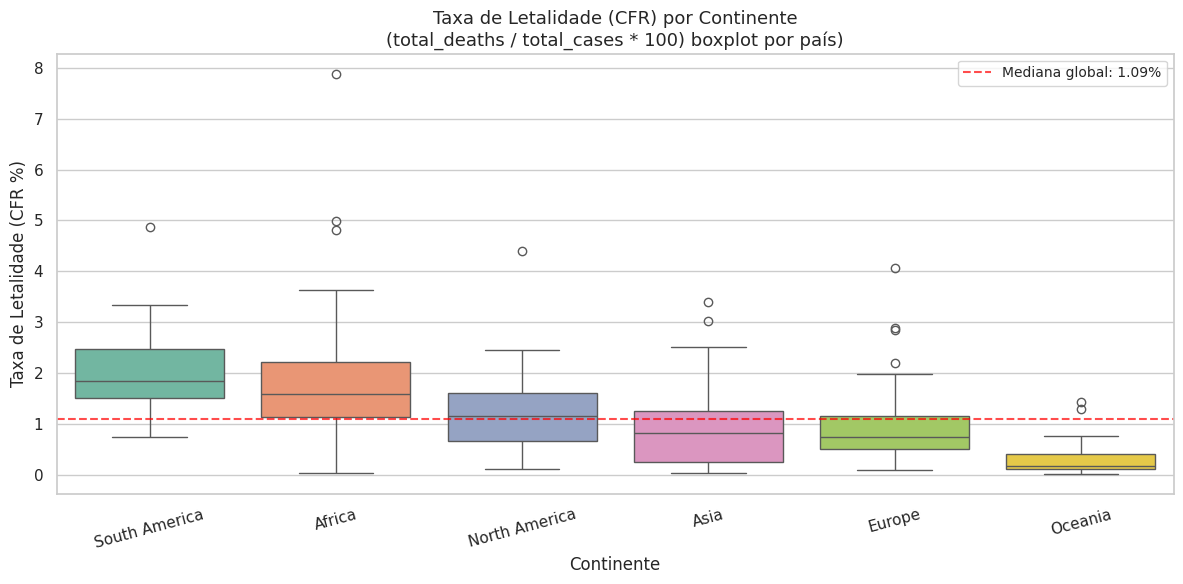

Figura salva: 12_cfr_continente_sim.png


In [ ]:
# GRÁFICO 12 CFR por continente
pdf_cfr = pdf_pais.copy()
pdf_cfr = pdf_cfr.dropna(subset=['total_deaths', 'total_cases'])
pdf_cfr = pdf_cfr[pdf_cfr['total_cases'] > 1000]  # Remove países com poucos casos
pdf_cfr['cfr'] = pdf_cfr['total_deaths'] / pdf_cfr['total_cases'] * 100

fig, ax = plt.subplots(figsize=(12, 6))
ordem_cont = (pdf_cfr.groupby('continent')['cfr'].median()
              .sort_values(ascending=False).index.tolist())
sns.boxplot(data=pdf_cfr, x='continent', y='cfr', order=ordem_cont,
            palette='Set2', ax=ax)
ax.set_xlabel('Continente', fontsize=12)
ax.set_ylabel('Taxa de Letalidade (CFR %)', fontsize=12)
ax.set_title('Taxa de Letalidade (CFR) por Continente\n(total_deaths / total_cases * 100) boxplot por país)', fontsize=13)
ax.tick_params(axis='x', rotation=15)

# Linha de referência — CFR global
cfr_global = pdf_cfr['cfr'].median()
ax.axhline(cfr_global, color='red', linestyle='--', alpha=0.7,
           label=f'Mediana global: {cfr_global:.2f}%')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '12_cfr_continente_sim.png'), dpi=120)
plt.show()
print('Figura salva: 12_cfr_continente_sim.png')

---
## Seção 12: Correlação Socioeconômica

Analisa a relação entre fatores socioeconômicos (PIB, idade mediana, expectativa de vida) e o impacto da COVID-19.

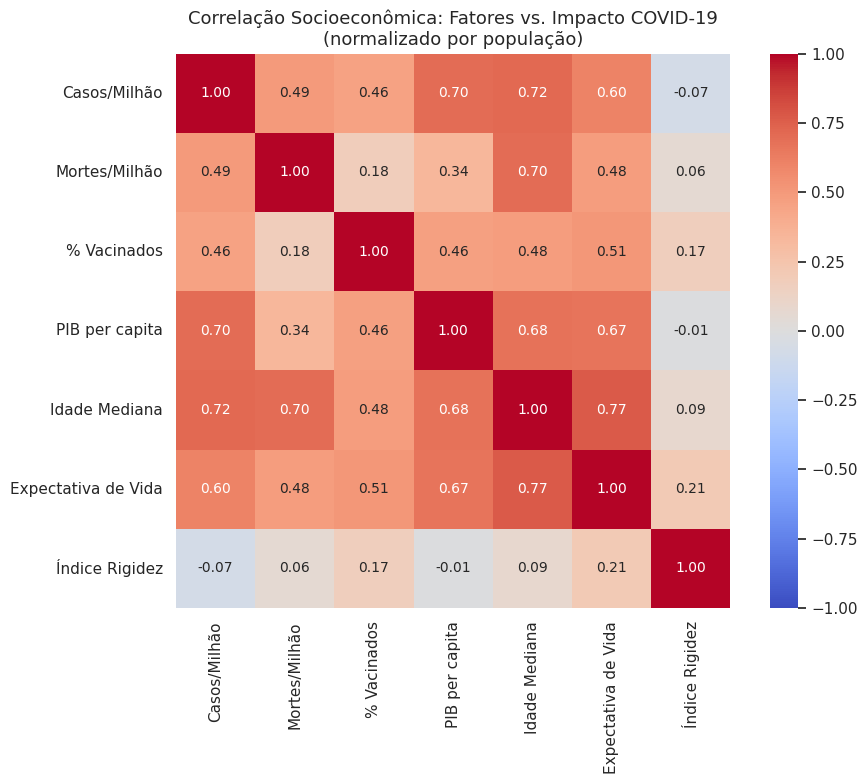

Figura salva: 13_correlacao_socioeconomica_sim.png

Pares de países usados na correlação: 191


In [ ]:
# GRÁFICO 13 Matriz de correlação socioeconômica
variaveis_corr = [
    'total_cases', 'total_deaths', 'people_fully_vaccinated',
    'gdp_per_capita', 'median_age', 'life_expectancy', 'avg_stringency_index',
]
variaveis_existentes = [v for v in variaveis_corr if v in pdf_pais.columns]

pdf_corr = pdf_pais[variaveis_existentes].dropna()

# Normaliza casos e mortes por população para comparação justa
if 'population' in pdf_pais.columns:
    pdf_pais_norm = pdf_pais.copy()
    pdf_pais_norm['casos_por_milhao'] = pdf_pais_norm['total_cases'] / pdf_pais_norm['population'] * 1e6
    pdf_pais_norm['mortes_por_milhao'] = pdf_pais_norm['total_deaths'] / pdf_pais_norm['population'] * 1e6
    pdf_pais_norm['pct_vacinados'] = pdf_pais_norm['people_fully_vaccinated'] / pdf_pais_norm['population'] * 100
    vars_norm = ['casos_por_milhao', 'mortes_por_milhao', 'pct_vacinados',
                 'gdp_per_capita', 'median_age', 'life_expectancy', 'avg_stringency_index']
    vars_norm = [v for v in vars_norm if v in pdf_pais_norm.columns]
    pdf_corr = pdf_pais_norm[vars_norm]

corr_matrix = pdf_corr.corr(min_periods=5)

nomes_pt = {
    'casos_por_milhao': 'Casos/Milhão',
    'mortes_por_milhao': 'Mortes/Milhão',
    'pct_vacinados': '% Vacinados',
    'gdp_per_capita': 'PIB per capita',
    'median_age': 'Idade Mediana',
    'life_expectancy': 'Expectativa de Vida',
    'avg_stringency_index': 'Índice Rigidez',
}
corr_matrix = corr_matrix.rename(index=nomes_pt, columns=nomes_pt)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 10}, square=True)
ax.set_title('Correlação Socioeconômica: Fatores vs. Impacto COVID-19\n(normalizado por população)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '13_correlacao_socioeconomica_sim.png'), dpi=120)
plt.show()
print('Figura salva: 13_correlacao_socioeconomica_sim.png')
print(f'\nPares de países usados na correlação: {len(pdf_corr)}')

---
## Seção 13: PIB per capita vs. Vacinação

Scatter plot que relaciona a riqueza do país (PIB per capita) com a taxa de vacinação, revelando desigualdades globais.

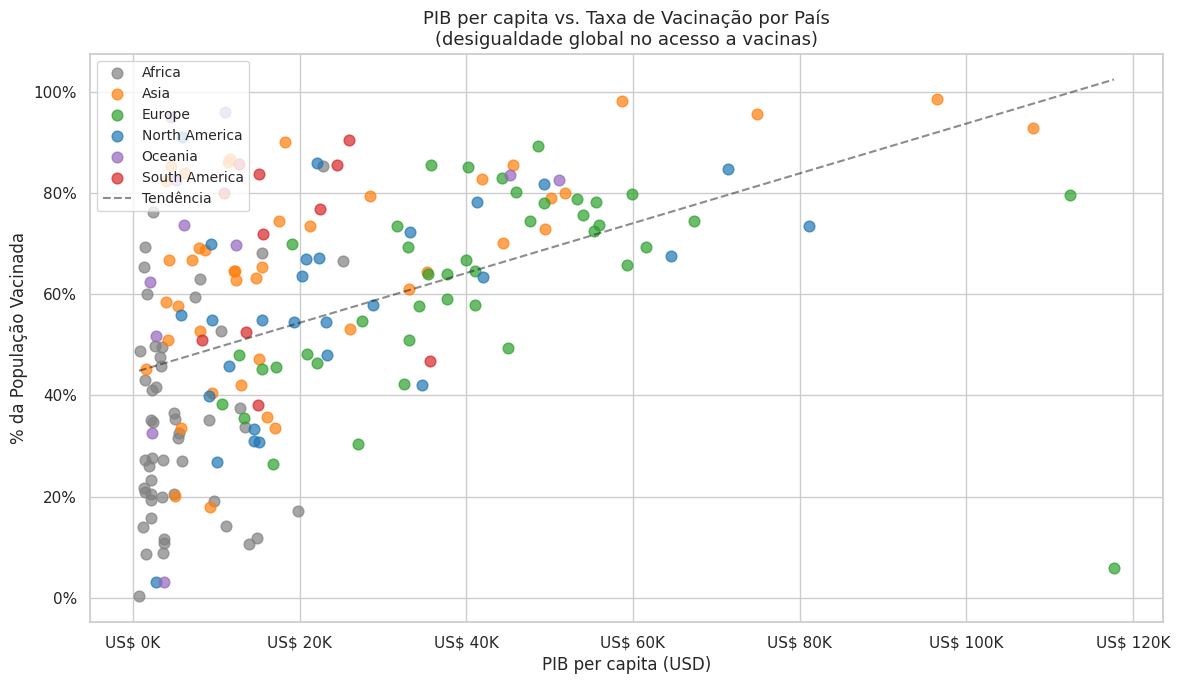

Figura salva: 14_pib_vs_vacinacao_sim.png


In [ ]:
# GRÁFICO 14 PIB vs Vacinação (scatter por continente)
pdf_scatter = pdf_pais.copy()
pdf_scatter['pct_vacinados'] = (
    pdf_scatter['people_fully_vaccinated'] / pdf_scatter['population'] * 100
)
pdf_scatter = (
    pdf_scatter
    .dropna(subset=['gdp_per_capita', 'pct_vacinados'])
    .query('pct_vacinados <= 100')
)

fig, ax = plt.subplots(figsize=(12, 7))
for cont in sorted(pdf_scatter['continent'].dropna().unique()):
    dados = pdf_scatter[pdf_scatter['continent'] == cont]
    ax.scatter(dados['gdp_per_capita'], dados['pct_vacinados'],
               label=cont, alpha=0.7, s=60,
               color=cont_cores.get(cont, 'gray'))

# Linha de tendência
z = np.polyfit(pdf_scatter['gdp_per_capita'], pdf_scatter['pct_vacinados'], 1)
p = np.poly1d(z)
x_range = np.linspace(pdf_scatter['gdp_per_capita'].min(),
                      pdf_scatter['gdp_per_capita'].max(), 100)
ax.plot(x_range, p(x_range), 'k--', alpha=0.5, linewidth=1.5, label='Tendência')

ax.set_xlabel('PIB per capita (USD)', fontsize=12)
ax.set_ylabel('% da População Vacinada', fontsize=12)
ax.set_title('PIB per capita vs. Taxa de Vacinação por País\n(desigualdade global no acesso a vacinas)', fontsize=13)
ax.legend(fontsize=10, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'US$ {x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '14_pib_vs_vacinacao_sim.png'), dpi=120)
plt.show()
print('Figura salva: 14_pib_vs_vacinacao_sim.png')

---
## Seção 14: Taxa de Reprodução (Rt)

O **número de reprodução** (Rt) indica quantas pessoas cada infectado contagia. Rt > 1 = crescimento epidêmico; Rt < 1 = controle.

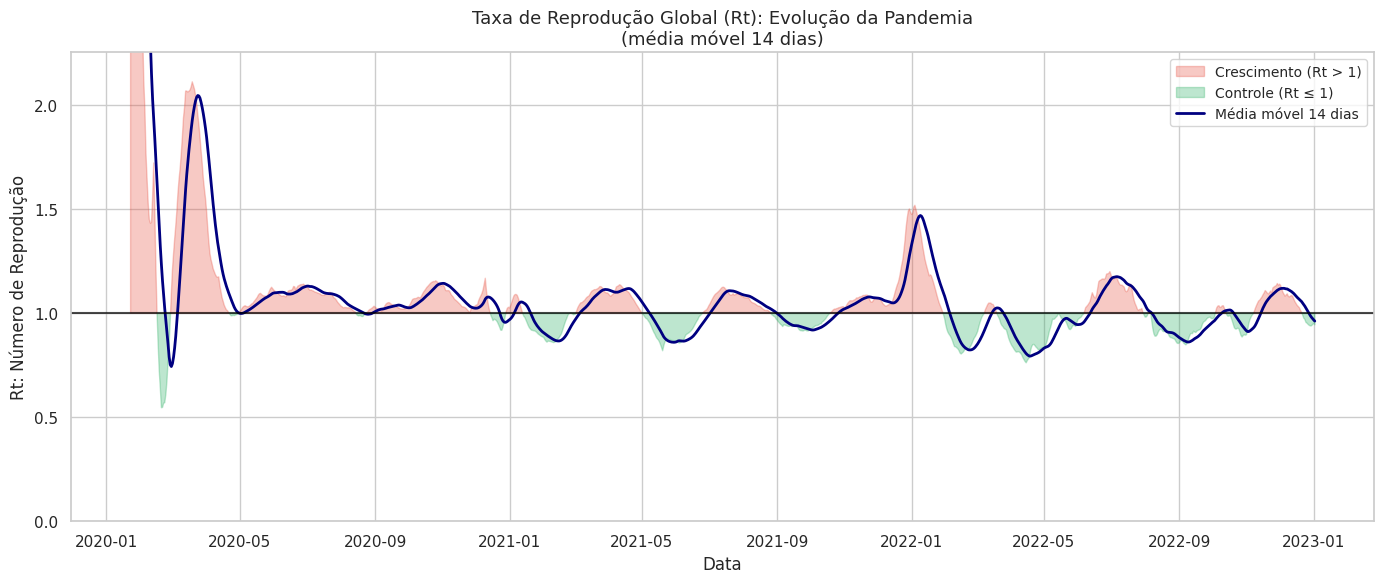

Figura salva: 15_taxa_reproducao_sim.png


In [ ]:
# GRÁFICO 15 Taxa de reprodução global ao longo do tempo
pdf_rt_world = (
    pdf_bruto[pdf_bruto['country'] == 'World']
    .dropna(subset=['reproduction_rate'])
    .copy()
)
pdf_rt_world['rt_ma14'] = pdf_rt_world['reproduction_rate'].rolling(14, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(pdf_rt_world['date'],
                pdf_rt_world['reproduction_rate'],
                1, where=(pdf_rt_world['reproduction_rate'] > 1),
                interpolate=True, color='#e74c3c', alpha=0.3, label='Crescimento (Rt > 1)')
ax.fill_between(pdf_rt_world['date'],
                pdf_rt_world['reproduction_rate'],
                1, where=(pdf_rt_world['reproduction_rate'] <= 1),
                interpolate=True, color='#27ae60', alpha=0.3, label='Controle (Rt ≤ 1)')
ax.plot(pdf_rt_world['date'], pdf_rt_world['rt_ma14'],
        color='navy', linewidth=2, label='Média móvel 14 dias')
ax.axhline(1, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Rt: Número de Reprodução', fontsize=12)
ax.set_title('Taxa de Reprodução Global (Rt): Evolução da Pandemia\n(média móvel 14 dias)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, pdf_rt_world['reproduction_rate'].quantile(0.98) + 0.2)

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '15_taxa_reproducao_sim.png'), dpi=120)
plt.show()
print('Figura salva: 15_taxa_reproducao_sim.png')

---
## Seção 15: Índice de Rigidez (Stringency Index)

O **Stringency Index** (Oxford COVID-19 Government Response Tracker) mede a rigidez das restrições governamentais, de 0 (nenhuma restrição) a 100 (máximo de restrições).

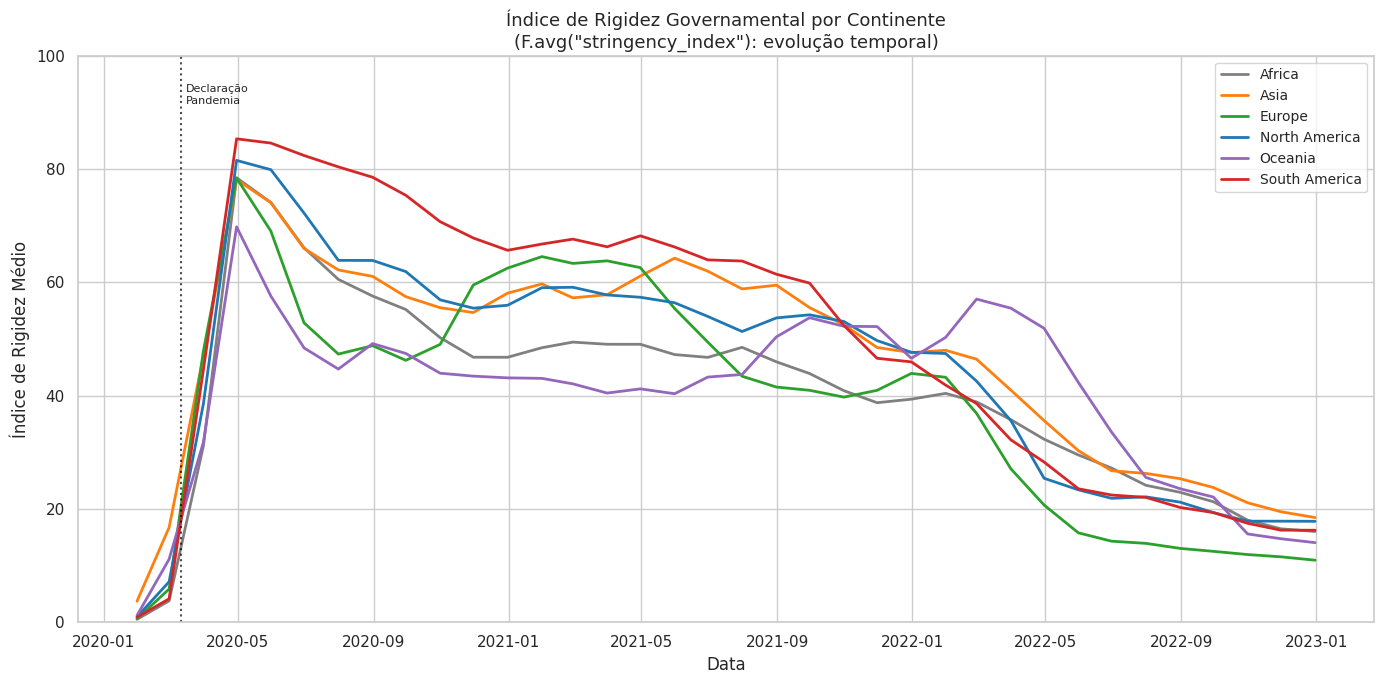

Figura salva: 16_indice_rigidez_sim.png


In [ ]:
# GRÁFICO 16 Índice de rigidez por continente ao longo do tempo
pdf_si = (
    pdf_bruto[pdf_bruto['continent'].notna()]
    .groupby(['continent', pd.Grouper(key='date', freq='ME')])
    ['stringency_index'].mean().reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))
for cont in sorted(pdf_si['continent'].dropna().unique()):
    dados = pdf_si[pdf_si['continent'] == cont].dropna(subset=['stringency_index'])
    ax.plot(dados['date'], dados['stringency_index'],
            label=cont, linewidth=2, color=cont_cores.get(cont, 'gray'))

ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Índice de Rigidez Médio', fontsize=12)
ax.set_title('Índice de Rigidez Governamental por Continente\n(F.avg("stringency_index"): evolução temporal)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 100)

# Anotações de marcos pandêmicos
ax.axvline(pd.Timestamp('2020-03-11'), color='black', linestyle=':', alpha=0.7)
ax.text(pd.Timestamp('2020-03-15'), 95, 'Declaração\nPandemia', fontsize=8, va='top')

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '16_indice_rigidez_sim.png'), dpi=120)
plt.show()
print('Figura salva: 16_indice_rigidez_sim.png')

---
## Seção 16: Window Function: Média Móvel por País

Demonstração explícita da **Window Function** simulada, mostrando a média móvel de 7 dias para países selecionados.

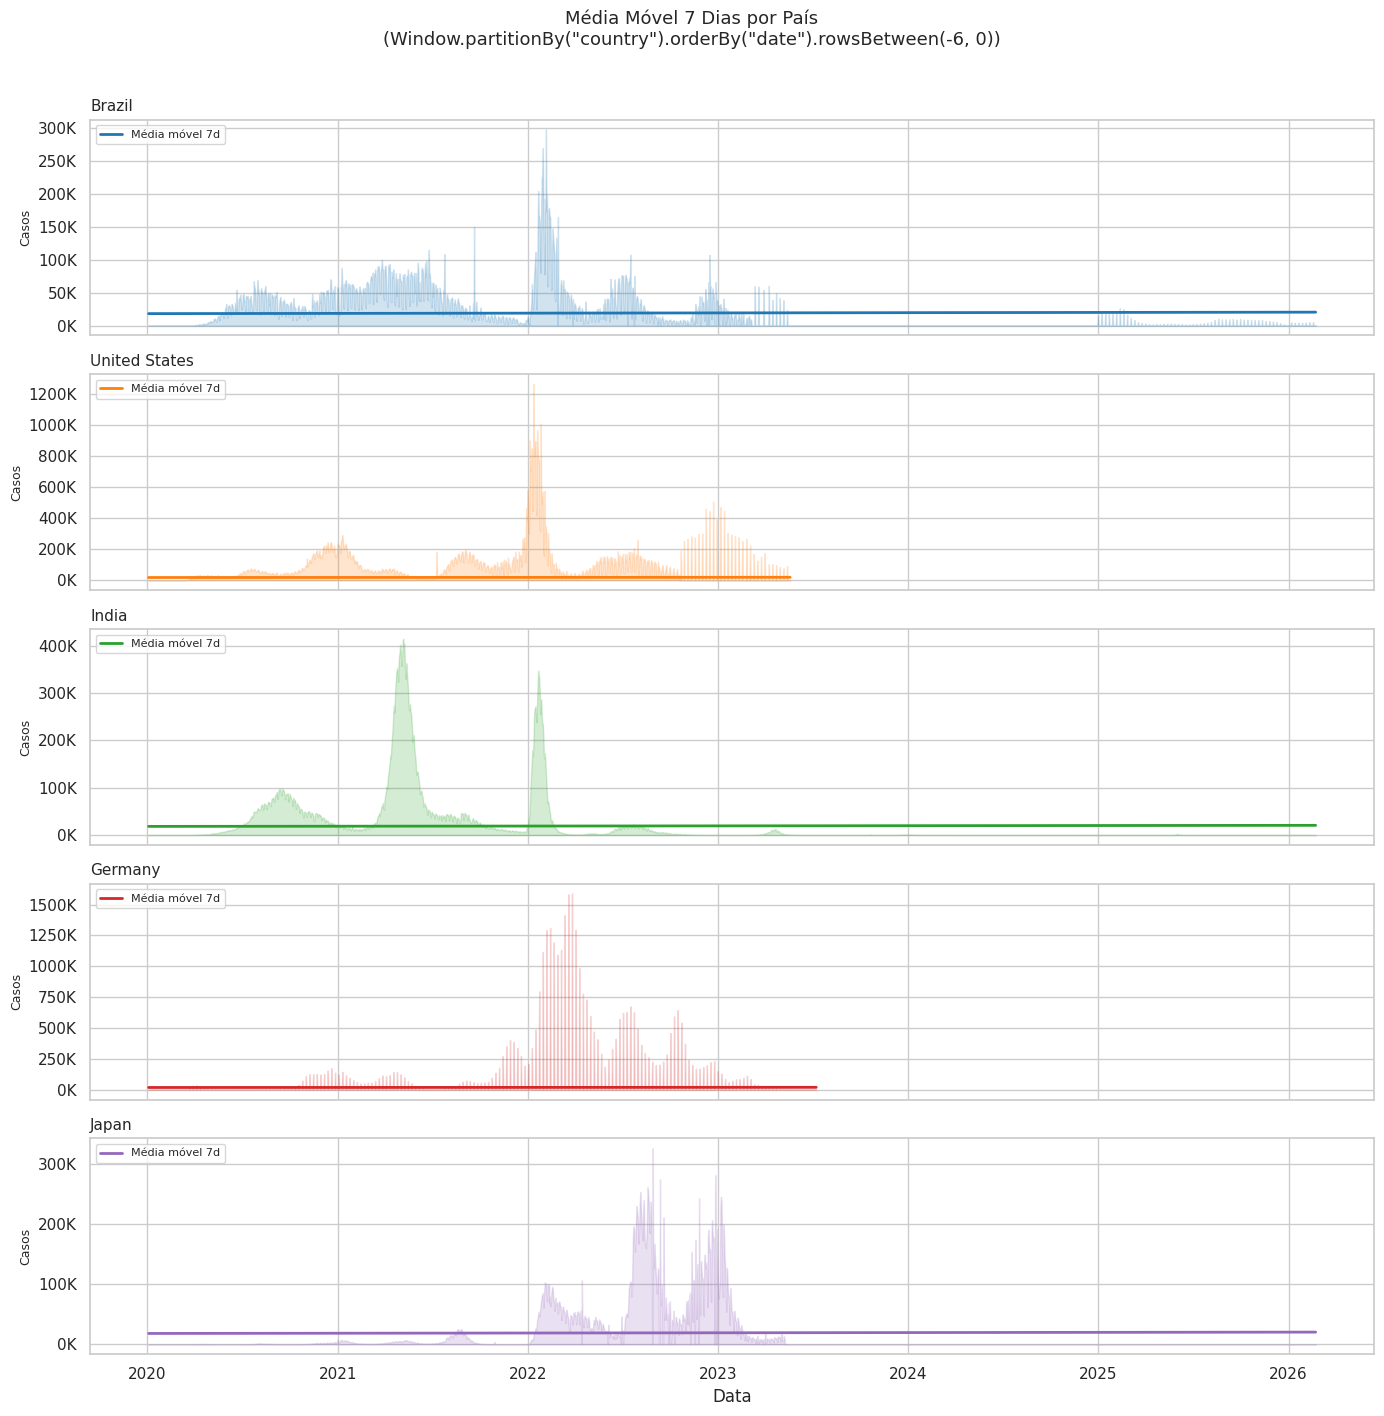

Figura salva: 17_media_movel_paises_sim.png


In [ ]:
# GRÁFICO 17 Média móvel 7 dias para países selecionados
paises_sel = ['Brazil', 'United States', 'India', 'Germany', 'Japan']

fig, axes = plt.subplots(len(paises_sel), 1, figsize=(14, 14), sharex=True)
cores_pais = sns.color_palette('tab10', len(paises_sel))

for i, pais in enumerate(paises_sel):
    dados_pais = (
        pdf[pdf['country'] == pais]
        .dropna(subset=['new_cases'])
        .sort_values('date')
    )
    if len(dados_pais) == 0:
        axes[i].set_title(f'{pais}: sem dados')
        continue

    axes[i].fill_between(dados_pais['date'], dados_pais['new_cases'],
                         alpha=0.2, color=cores_pais[i])
    axes[i].plot(dados_pais['date'], dados_pais['new_cases_ma7'],
                 color=cores_pais[i], linewidth=2, label='Média móvel 7d')
    axes[i].set_ylabel('Casos', fontsize=9)
    axes[i].set_title(pais, fontsize=11, loc='left')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    axes[i].legend(fontsize=8, loc='upper left')

axes[-1].set_xlabel('Data', fontsize=12)
fig.suptitle('Média Móvel 7 Dias por País\n(Window.partitionBy("country").orderBy("date").rowsBetween(-6, 0))',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '17_media_movel_paises_sim.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Figura salva: 17_media_movel_paises_sim.png')

---
## Seção 17: Load: Salvando Resultados

> **Conceito Spark:** Na última etapa do pipeline ETL (**Load**), os DataFrames transformados são persistidos em disco.

In [ ]:
# LOAD alva os três datasets processados
from simulacao import salvar

print('Salvando resultados...')
salvar(df_pais, 'resumo_por_pais_sim')
salvar(df_mensal, 'evolucao_mensal_sim')
salvar(df_cont, 'resumo_continente_sim')
print('\nLoad concluído!')

Salvando resultados...
  Salvo: /home/isabela-carone/Área de trabalho/repositorios-uvv/eda-covid19/eda-covid19/data/processado_sim/resumo_por_pais_sim.csv
  Salvo: /home/isabela-carone/Área de trabalho/repositorios-uvv/eda-covid19/eda-covid19/data/processado_sim/evolucao_mensal_sim.csv
  Salvo: /home/isabela-carone/Área de trabalho/repositorios-uvv/eda-covid19/eda-covid19/data/processado_sim/resumo_continente_sim.csv

Load concluído!


---
## Seção 18: Encerramento

Exibe o resumo das figuras geradas e encerra a sessão simulada.

In [ ]:
# Lista as figuras geradas pela simulação
figuras_sim = sorted([
    f for f in os.listdir(DIR_FIGURAS)
    if f.endswith('_sim.png')
])

print(f'Figuras geradas pela simulação ({len(figuras_sim)} total):')
for fig_nome in figuras_sim:
    print(f'  ✓ {fig_nome}')

print()
spark.stop()
print('Pipeline de simulação do Apache Spark concluído!')

Figuras geradas pela simulação (22 total):
  ✓ 01_valores_nulos_sim.png
  ✓ 02_mapreduce_sim.png
  ✓ 03_evolucao_global_sim.png
  ✓ 04_evolucao_mensal_sim.png
  ✓ 05_top15_casos_sim.png
  ✓ 06_top15_mortes_sim.png
  ✓ 07_top15_mortes_por_milhao_sim.png
  ✓ 08_analise_continentes_sim.png
  ✓ 09_casos_por_continente_tempo_sim.png
  ✓ 10_vacinacao_global_sim.png
  ✓ 11_top20_vacinacao_sim.png
  ✓ 12_cfr_continente_sim.png
  ✓ 13_correlacao_socioeconomica_sim.png
  ✓ 14_pib_vs_vacinacao_sim.png
  ✓ 15_taxa_reproducao_sim.png
  ✓ 16_indice_rigidez_sim.png
  ✓ 17_media_movel_paises_sim.png
  ✓ 18_curva_epidemica_sim.png
  ✓ 19_incidencia_100k_sim.png
  ✓ 20_cfr_temporal_sim.png
  ✓ 21_mortalidade_100k_sim.png
  ✓ 22_stringency_vs_rt_sim.png


SimulatedSparkSession encerrada.

Pipeline de simulação do Apache Spark concluído!


---
## Seção 19: Análises Epidemiológicas Complementares

Este bloco replica no notebook de simulação as análises epidemiológicas finais do notebook principal.

In [ ]:
# Figura 18: Curva epidêmica global
pdf_epi = (
    df_completo._pdf
    .dropna(subset=['date', 'new_cases'])
    .groupby('date', as_index=False)['new_cases']
    .sum()
    .rename(columns={'new_cases': 'global_new_cases'})
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(pdf_epi['date'], pdf_epi['global_new_cases'], width=5, color='steelblue', alpha=0.65)

ondas = [
    ('2020-03-01', '2020-06-30', '1ª onda', '#f9c74f'),
    ('2020-10-01', '2021-03-31', '2ª onda', '#f9844a'),
    ('2021-06-01', '2022-03-31', '3ª onda (Delta/Omicron)', '#f94144'),
]

for start, end, label, color in ondas:
    s = pd.to_datetime(start)
    e = pd.to_datetime(end)
    if s > pdf_epi['date'].max():
        continue
    ax.axvspan(s, min(e, pdf_epi['date'].max()), alpha=0.22, color=color, label=label)

ax.set_title('Curva Epidêmica Global — Novos Casos Diários', fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('Novos casos')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '18_curva_epidemica_sim.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Figura salva: 18_curva_epidemica_sim.png')

In [ ]:
# Figura 19: Incidência mensal por 100 mil habitantes (continentes)
pdf_inc = df_completo._pdf.copy()
pdf_inc = pdf_inc[pdf_inc['continent'].notna() & (~pdf_inc['continent'].isin(REGIOES_AGREGADAS))]

incid = (
    pdf_inc
    .groupby(['continent', 'year_month'], as_index=False)
    .agg({'new_cases': 'sum', 'population': 'sum'})
)
incid = incid[incid['population'] > 0]
incid['incidencia_100k'] = (incid['new_cases'] / incid['population']) * 100000
incid['mes_dt'] = pd.to_datetime(incid['year_month'] + '-01')

fig, ax = plt.subplots(figsize=(13, 6))
for cont in sorted(incid['continent'].dropna().unique()):
    dados = incid[(incid['continent'] == cont) & (incid['incidencia_100k'].notna())]
    if len(dados) == 0:
        continue
    ax.plot(dados['mes_dt'], dados['incidencia_100k'], linewidth=2, label=cont)

ax.set_title('Incidência Mensal de COVID-19 por Continente (por 100 mil hab.)', fontsize=13)
ax.set_xlabel('Mês')
ax.set_ylabel('Incidência por 100 mil')
ax.legend(title='Continente', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '19_incidencia_100k_sim.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Figura salva: 19_incidencia_100k_sim.png')

In [ ]:
# Figura 20: CFR temporal por continente
pdf_cfr = df_completo._pdf.copy()
pdf_cfr = pdf_cfr[pdf_cfr['continent'].notna() & (~pdf_cfr['continent'].isin(REGIOES_AGREGADAS))]

cfr_t = (
    pdf_cfr
    .groupby(['continent', 'year_month'], as_index=False)
    .agg({'new_cases': 'sum', 'new_deaths': 'sum'})
)
cfr_t = cfr_t[cfr_t['new_cases'] > 0]
cfr_t['cfr_pct'] = (cfr_t['new_deaths'] / cfr_t['new_cases']) * 100
cfr_t['mes_dt'] = pd.to_datetime(cfr_t['year_month'] + '-01')

fig, ax = plt.subplots(figsize=(13, 6))
for cont in sorted(cfr_t['continent'].dropna().unique()):
    dados = cfr_t[(cfr_t['continent'] == cont) & (cfr_t['cfr_pct'].notna())]
    if len(dados) == 0:
        continue
    ax.plot(dados['mes_dt'], dados['cfr_pct'], linewidth=2, label=cont)

ax.set_title('Taxa de Letalidade Temporal (CFR %) por Continente', fontsize=13)
ax.set_xlabel('Mês')
ax.set_ylabel('CFR (%)')
ax.legend(title='Continente', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '20_cfr_temporal_sim.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Figura salva: 20_cfr_temporal_sim.png')

In [ ]:
# Figura 21: Top 20 países por mortalidade por 100 mil habitantes
mort = (
    df_completo._pdf
    .dropna(subset=['country', 'continent', 'population', 'total_deaths'])
)
mort = mort[(~mort['continent'].isin(REGIOES_AGREGADAS)) & (mort['population'] > 0)]

mort_pais = (
    mort
    .groupby(['country', 'continent', 'population'], as_index=False)['total_deaths']
    .max()
)
mort_pais['mortalidade_100k'] = (mort_pais['total_deaths'] / mort_pais['population']) * 100000

top20_mort = (
    mort_pais
    .dropna(subset=['mortalidade_100k'])
    .query('mortalidade_100k > 0')
    .nlargest(20, 'mortalidade_100k')
)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top20_mort['country'][::-1], top20_mort['mortalidade_100k'][::-1], color='#c0392b', alpha=0.85)
ax.set_title('Top 20 Países por Mortalidade (óbitos por 100 mil hab.)', fontsize=13)
ax.set_xlabel('Óbitos por 100 mil habitantes')
ax.set_ylabel('País')
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '21_mortalidade_100k_sim.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Figura salva: 21_mortalidade_100k_sim.png')

In [ ]:
# Figura 22: Relação entre rigidez e Rt médio por país
scatter = (
    df_completo._pdf
    .dropna(subset=['country', 'continent', 'stringency_index', 'reproduction_rate'])
)
scatter = scatter[~scatter['continent'].isin(REGIOES_AGREGADAS)]

scatter_pais = (
    scatter
    .groupby(['country', 'continent'], as_index=False)
    .agg({
        'stringency_index': 'mean',
        'reproduction_rate': 'mean',
    })
    .rename(columns={
        'stringency_index': 'avg_stringency_index',
        'reproduction_rate': 'avg_reproduction_rate',
    })
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=scatter_pais,
    x='avg_stringency_index',
    y='avg_reproduction_rate',
    hue='continent',
    alpha=0.75,
    s=45,
    ax=ax,
)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax.set_title('Índice de Rigidez Médio vs Taxa de Reprodução Média (por país)', fontsize=13)
ax.set_xlabel('Stringency Index médio')
ax.set_ylabel('Rt médio')
ax.legend(title='Continente', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIGURAS, '22_stringency_vs_rt_sim.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Figura salva: 22_stringency_vs_rt_sim.png')